#**Retail Store Sales Analysis and Prediction**

##**Introduction**
This project focuses on analysing retail store sales data using data
science and machine learning techniques. The main purpose is to
understand customer purchasing patterns and classify customer spending
behaviour into Low, Medium, and High categories.

Data cleaning, exploratory data analysis (EDA), feature engineering,
and machine learning models including Logistic Regression, KNN,
Decision Tree, and Random Forest were applied and compared to identify
the best classification model.

The project demonstrates how machine learning can support retail
business decision-making and improve sales understanding.

##**Problem Statement**

Retail businesses often face challenges in understanding customer
behaviour and predicting sales trends accurately. Large datasets may
contain missing values, inconsistent data, and complex patterns that
are difficult to analyse manually. Without proper analysis, businesses
may face problems such as poor sales forecasting, inefficient inventory
management, and weak business strategies. Therefore, this project aims
to use data analysis and machine learning classification techniques to
classify customer spending behaviour and identify patterns for better
business decision-making.

##**Project Objectives**


- To clean and preprocess the retail sales dataset.
- To perform exploratory data analysis (EDA) to understand data patterns and trends.
- To apply feature engineering techniques to create new meaningful features.
- To build and compare different machine learning classification models.
- To evaluate model performance using classification metrics such as
  Accuracy, Precision, Recall, and F1-Score.
- To identify the best-performing model for customer spending prediction.
- To generate business insights and recommendations based on the analysis results.

##Import Libraries and Dataset Loading





In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Make plots look clean
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


Obervation:

The required libraries for data analysis, visualization, preprocessing, machine learning, and evaluation are successfully imported. These libraries will be used throughout the project.

In [ ]:
# Load the dataset
df = pd.read_csv('https://raw.githubusercontent.com/maybraniswe/Retail-Store-Sales-Analysis-and-Prediction/refs/heads/main/retail_store_sales.csv')

# Check dataset size
df.shape

(12575, 11)

Observation:

The dataset is successfully loaded into pandas DataFrame. The dataset contains 12,575 rows and 11 columns, which is suitable for analysis and machine learning tasks.

##Initial Data Inspection

In [ ]:
# Display first 5 rows
df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


Observation:

The dataset contains transaction details such as customer ID, category, item name, quantity, payment method, location, and total spent. Some missing values can also be seen in the dataset.

In [ ]:
# Display statistical summary for numerical columns
df.describe().round(2)

,Price Per Unit,Quantity,Total Spent
count,11966.00,11971.00,11971.00
mean,23.37,5.54,129.65
std,10.74,2.86,94.75
min,5.00,1.00,5.00
25%,14.00,3.00,51.00
50%,23.00,6.00,108.50
75%,33.50,8.00,192.00
max,41.00,10.00,410.00


Observation:

The numerical columns show different ranges of values. Price Per Unit ranges from 5 to 41, while Quantity ranges from 1 to 10. Total Spent has a wide range, showing differences in customer purchases.

In [ ]:
# Display full data information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              11362 non-null  object 
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(8)
memory usage: 1.1+ MB


Observation:

The dataset contains both numerical and categorical data types. Some columns such as Transaction Date and Discount Applied need further preprocessing before modeling.

In [ ]:
# Check missing values
df.isnull().sum()

,0
Transaction ID,0
Customer ID,0
Category,0
Item,1213
Price Per Unit,609
Quantity,604
Total Spent,604
Payment Method,0
Location,0
Transaction Date,0


Observation:

Missing values are found in Item, Price Per Unit, Quantity, Total Spent, and Discount Applied columns. These missing values need to be handled before analysis and machine learning.

##Data Cleaning


In [ ]:
# ==========================================================
# DATA CLEANING
# ==========================================================

# Create a copy of original dataset
clean_df = df.copy()

# Check original shape
print("Original dataset shape:", clean_df.shape)

Original dataset shape: (12575, 11)


Observation:

A copy of the dataset is created before cleaning. This helps keep the original dataset unchanged.

In [ ]:
# ==========================================================
# REMOVE DUPLICATE ROWS
# ==========================================================

duplicate_count = clean_df.duplicated().sum()
print("Duplicate rows before cleaning:", duplicate_count)

clean_df = clean_df.drop_duplicates()

print("Duplicate rows after cleaning:", clean_df.duplicated().sum())
print("Dataset shape after removing duplicates:", clean_df.shape)

Duplicate rows before cleaning: 0
Duplicate rows after cleaning: 0
Dataset shape after removing duplicates: (12575, 11)


Observation:

No duplicate rows were found in the dataset. The dataset remains the same after checking duplicates.

In [ ]:
# ==========================================================
# CONVERT TRANSACTION DATE TO DATETIME
# ==========================================================

clean_df["Transaction Date"] = pd.to_datetime(
    clean_df["Transaction Date"],
    errors="coerce"
)

clean_df["Transaction Date"].dtype

dtype('<M8[ns]')

Observation:

Transaction Date is successfully converted into datetime format. This makes date-based analysis easier.

In [ ]:
# ==========================================================
# STANDARDIZE CATEGORICAL TEXT COLUMNS
# ==========================================================

categorical_cols = [
    "Transaction ID",
    "Customer ID",
    "Category",
    "Item",
    "Payment Method",
    "Location",
    "Discount Applied"
]

for col in categorical_cols:
    clean_df[col] = clean_df[col].astype(str).str.strip().str.lower()

 # Convert fake string missing values back to real NaN
clean_df = clean_df.replace(
    ["nan", "none", ""],
    np.nan
)
clean_df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,txn_6867343,cust_09,patisserie,item_10_pat,18.5,10.0,185.0,digital wallet,online,2024-04-08,true
1,txn_3731986,cust_22,milk products,item_17_milk,29.0,9.0,261.0,digital wallet,online,2023-07-23,true
2,txn_9303719,cust_02,butchers,item_12_but,21.5,2.0,43.0,credit card,online,2022-10-05,false
3,txn_9458126,cust_06,beverages,item_16_bev,27.5,9.0,247.5,credit card,online,2022-05-07,NaN
4,txn_4575373,cust_05,food,item_6_food,12.5,7.0,87.5,digital wallet,online,2022-10-02,false


Observation:

Categorical text columns are standardized by converting all text into lowercase and removing extra spaces. Fake missing values such as "nan", "none", and empty strings are converted back to real NaN values for proper cleaning and analysis.

In [ ]:
# ==========================================================
# HANDLE MISSING VALUES
# ==========================================================

# Remove rows where both Item and Price Per Unit are missing
clean_df = clean_df.dropna(
    subset=["Item", "Price Per Unit"],
    how="all"
)

# Create reference table from available Item and Price Per Unit
item_price_table = clean_df[["Item", "Price Per Unit"]].dropna().drop_duplicates()

# Fill missing Item using Price Per Unit
price_to_item = item_price_table.drop_duplicates("Price Per Unit") \
                                .set_index("Price Per Unit")["Item"]

clean_df["Item"] = clean_df["Item"].fillna(
    clean_df["Price Per Unit"].map(price_to_item)
)

# Fill missing Price Per Unit using Item
item_to_price = item_price_table.drop_duplicates("Item") \
                                .set_index("Item")["Price Per Unit"]

clean_df["Price Per Unit"] = clean_df["Price Per Unit"].fillna(
    clean_df["Item"].map(item_to_price)
)

# Fill Quantity using median
clean_df["Quantity"] = clean_df["Quantity"].fillna(
    clean_df["Quantity"].median()
)

# Recalculate Total Spent
clean_df["Total Spent"] = clean_df["Price Per Unit"] * clean_df["Quantity"]

# Fill Discount Applied
clean_df["Discount Applied"] = (
    clean_df["Discount Applied"]
    .map({"true": True, "false": False})
    .fillna(False)
    .astype(bool)
)

clean_df.isnull().sum()

/tmp/ipykernel_2253/395765695.py:42: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


,0
Transaction ID,0
Customer ID,0
Category,0
Item,0
Price Per Unit,0
Quantity,0
Total Spent,0
Payment Method,0
Location,0
Transaction Date,0


Observation:

Missing values are handled using different cleaning methods. Missing Item and Price Per Unit values are filled using related reference values. Quantity is filled using the median value, and Total Spent is recalculated for accuracy. Discount Applied is converted into boolean format.

After handling missing values, all columns show 0 missing values. This means the dataset is now fully cleaned and ready for analysis and machine learning modeling.

In [ ]:
# ==========================================================
# FINAL CLEAN DATA CHECK
# ==========================================================

print("Final dataset shape:", clean_df.shape)

print("\nFinal missing values:")
print(clean_df.isnull().sum())

print("\nFinal data types:")
print(clean_df.dtypes)

clean_df.head()

Final dataset shape: (11966, 11)

Final missing values:
Transaction ID      0
Customer ID         0
Category            0
Item                0
Price Per Unit      0
Quantity            0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
Discount Applied    0
dtype: int64

Final data types:
Transaction ID              object
Customer ID                 object
Category                    object
Item                        object
Price Per Unit             float64
Quantity                   float64
Total Spent                float64
Payment Method              object
Location                    object
Transaction Date    datetime64[ns]
Discount Applied              bool
dtype: object


,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,txn_6867343,cust_09,patisserie,item_10_pat,18.5,10.0,185.0,digital wallet,online,2024-04-08,True
1,txn_3731986,cust_22,milk products,item_17_milk,29.0,9.0,261.0,digital wallet,online,2023-07-23,True
2,txn_9303719,cust_02,butchers,item_12_but,21.5,2.0,43.0,credit card,online,2022-10-05,False
3,txn_9458126,cust_06,beverages,item_16_bev,27.5,9.0,247.5,credit card,online,2022-05-07,False
4,txn_4575373,cust_05,food,item_6_food,12.5,7.0,87.5,digital wallet,online,2022-10-02,False


Observation:

The final cleaned dataset contains 11,966 rows and 11 columns. All missing values have been successfully handled, and the data types are properly formatted for analysis and machine learning. The dataset is now clean, consistent, and ready for EDA and model building.

##Exploratory Data Analysis (EDA)

###Univariate Analysis

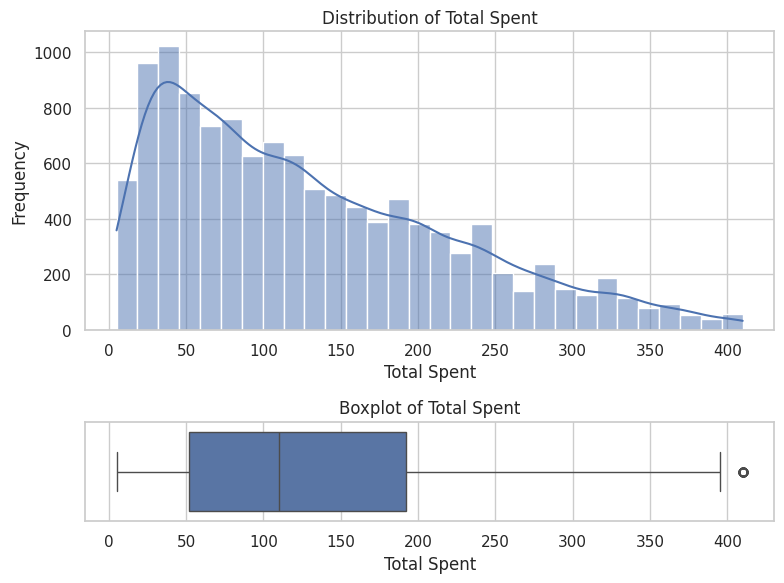

In [ ]:
# Histogram with KDE and Boxplot for Total Spent

fig, axes = plt.subplots(2, 1, figsize=(8, 6), gridspec_kw={"height_ratios": [3, 1]})

sns.histplot(clean_df["Total Spent"], kde=True, bins=30, ax=axes[0])
axes[0].set_title("Distribution of Total Spent")
axes[0].set_xlabel("Total Spent")
axes[0].set_ylabel("Frequency")

sns.boxplot(x=clean_df["Total Spent"], ax=axes[1])
axes[1].set_title("Boxplot of Total Spent")
axes[1].set_xlabel("Total Spent")

plt.tight_layout()
plt.show()


Observation:

The histogram shows that most customer transactions have lower to medium spending amounts, mainly between 20 and 150. The distribution is positively skewed, meaning fewer customers spend very high amounts. The KDE line confirms a gradual decrease in frequency as total spending increases.

The boxplot shows the spread of Total Spent values and identifies several high-value outliers above 400. Most transactions are concentrated within the middle range, while a small number of customers spend significantly more than average.

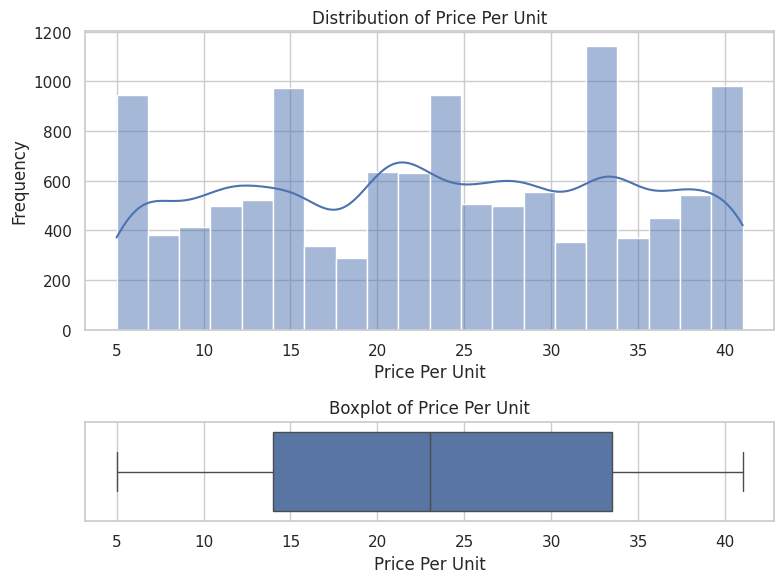

In [ ]:
# Histogram with KDE and Boxplot for Price Per Unit

fig, axes = plt.subplots(2, 1, figsize=(8, 6), gridspec_kw={"height_ratios": [3, 1]})

sns.histplot(clean_df["Price Per Unit"], kde=True, bins=20, ax=axes[0])
axes[0].set_title("Distribution of Price Per Unit")
axes[0].set_xlabel("Price Per Unit")
axes[0].set_ylabel("Frequency")

sns.boxplot(x=clean_df["Price Per Unit"], ax=axes[1])
axes[1].set_title("Boxplot of Price Per Unit")
axes[1].set_xlabel("Price Per Unit")

plt.tight_layout()
plt.show()

Observation:

The histogram shows that product prices are distributed across different price ranges from 5 to 40. The KDE line indicates that prices are relatively balanced without strong skewness, although some price points appear more frequently than others.

The boxplot indicates that the median price per unit is around the middle price range. The data does not show strong outliers, suggesting that product prices are relatively stable and evenly distributed.

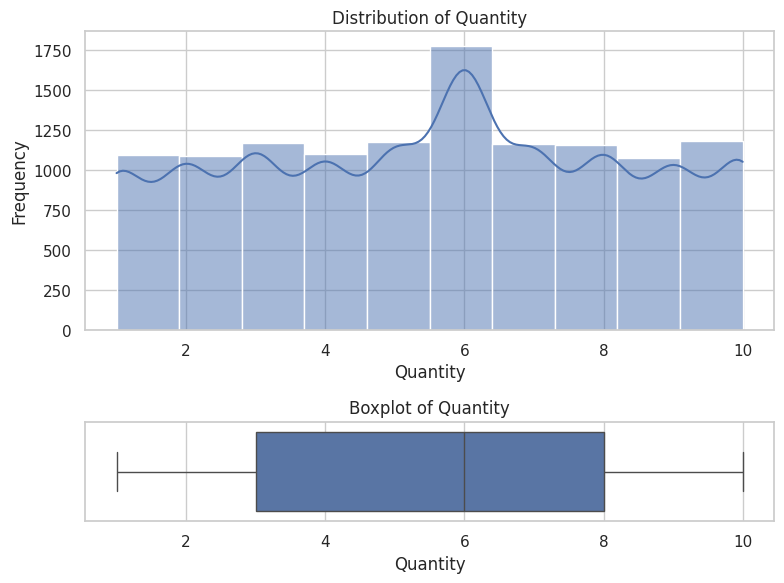

In [ ]:
# Histogram with KDE and Boxplot for Quantity

fig, axes = plt.subplots(2, 1, figsize=(8, 6), gridspec_kw={"height_ratios": [3, 1]})

sns.histplot(clean_df["Quantity"], kde=True, bins=10, ax=axes[0])
axes[0].set_title("Distribution of Quantity")
axes[0].set_xlabel("Quantity")
axes[0].set_ylabel("Frequency")

sns.boxplot(x=clean_df["Quantity"], ax=axes[1])
axes[1].set_title("Boxplot of Quantity")
axes[1].set_xlabel("Quantity")

plt.tight_layout()
plt.show()

Observation:

The histogram shows that customer purchase quantities are distributed fairly evenly between 1 and 10 items. Quantity 6 appears slightly more frequent compared to other quantities. The KDE line shows a generally balanced distribution pattern.

The boxplot shows that most purchase quantities fall between 3 and 8 items. There are no significant outliers, indicating that customers usually purchase within a normal quantity range.

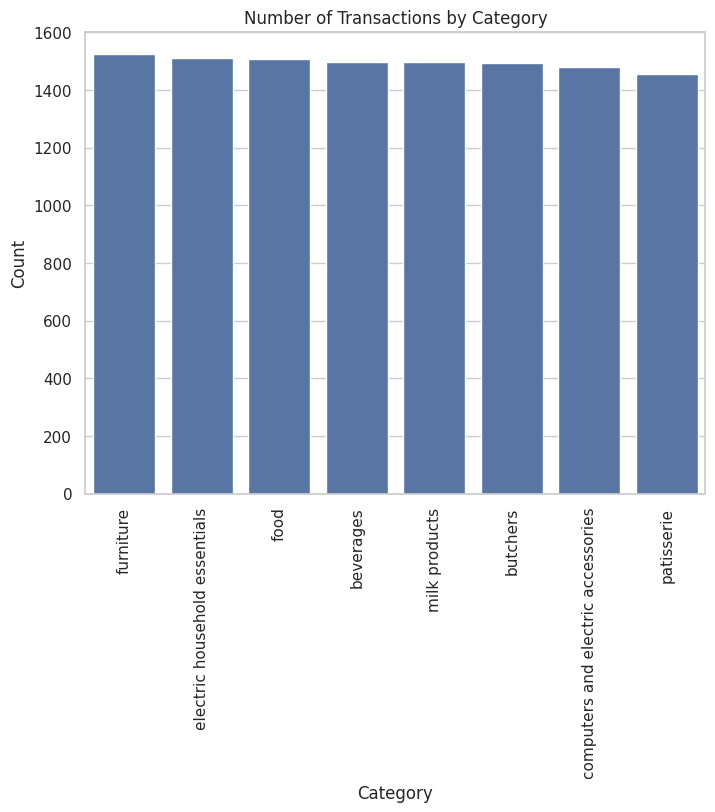

In [ ]:
# Countplot for Category

plt.figure(figsize=(8,6))

sns.countplot(data=clean_df, x="Category", order=clean_df["Category"].value_counts().index)

plt.title("Number of Transactions by Category")
plt.xlabel("Category")
plt.ylabel("Count")

plt.xticks(rotation=90)
plt.show()

Observation:

The bar chart shows that transaction counts are fairly balanced across all product categories. Furniture has the highest number of transactions, while patisserie has the lowest among the categories shown.

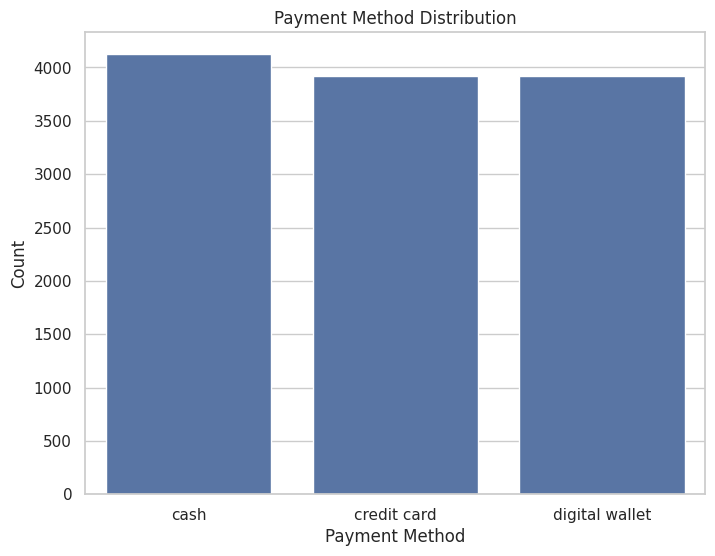

In [ ]:
# Countplot for Payment Method

plt.figure(figsize=(8,6))

sns.countplot(data=clean_df, x="Payment Method",
              order=clean_df["Payment Method"].value_counts().index)

plt.title("Payment Method Distribution")
plt.xlabel("Payment Method")
plt.ylabel("Count")

plt.show()

Observation:

The bar chart shows that all payment methods are commonly used by customers. Cash has the highest number of transactions, while credit card and digital wallet have slightly lower but similar transaction counts.

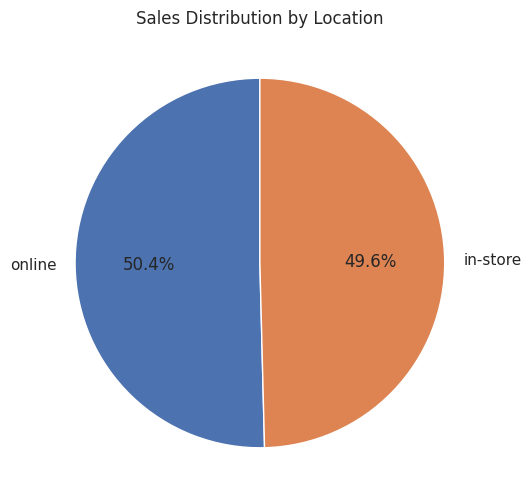

In [ ]:
# Pie chart for Location distribution

location_counts = clean_df["Location"].value_counts()

plt.figure(figsize=(8,6))

plt.pie(location_counts,
        labels=location_counts.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Sales Distribution by Location")

plt.show()

Observation:

The pie chart shows that sales are almost equally distributed between online and in-store transactions. Online sales account for 50.4% of total transactions, while in-store sales account for 49.6%, indicating balanced customer purchasing behavior across both sales channels.

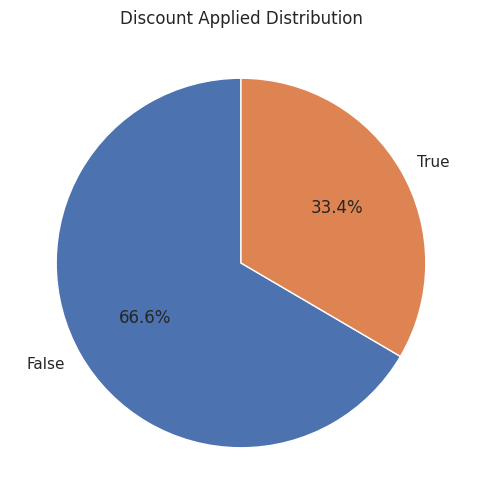

In [ ]:
# Pie chart for Discount Applied

discount_counts = clean_df["Discount Applied"].value_counts()

plt.figure(figsize=(8,6))

plt.pie(discount_counts,
        labels=discount_counts.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Discount Applied Distribution")

plt.show()

Observation:

The pie chart shows that most transactions did not receive a discount. Around 66.6% of transactions had no discount applied, while 33.4% received discounts. This indicates that discounts were used selectively and were applied to only a smaller portion of total sales.

###Bivariate Analysis


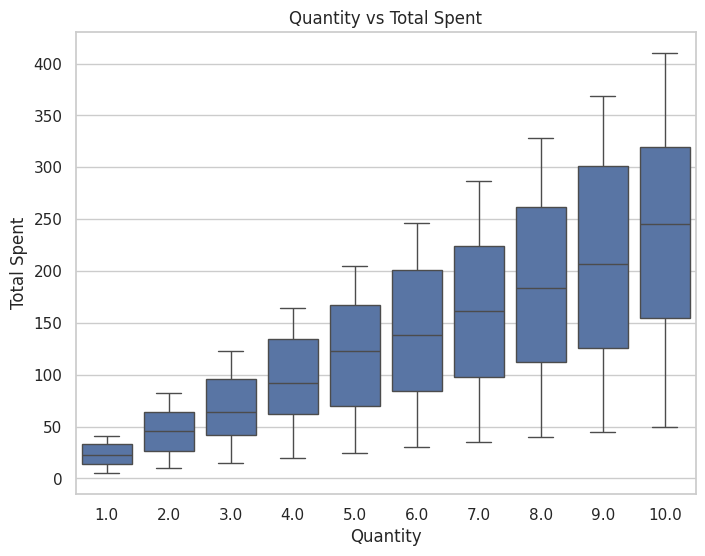

In [ ]:
# Boxplot: Quantity vs Total Spent

plt.figure(figsize=(8,6))

sns.boxplot(data=clean_df,
            x="Quantity",
            y="Total Spent")

plt.title("Quantity vs Total Spent")
plt.xlabel("Quantity")
plt.ylabel("Total Spent")

plt.show()

Observation:

The boxplot shows a positive relationship between quantity purchased and total spending. As the quantity increases, the median and overall range of total spending also increase. Customers who purchased larger quantities generally spent more money, although spending variability becomes wider at higher quantity levels.

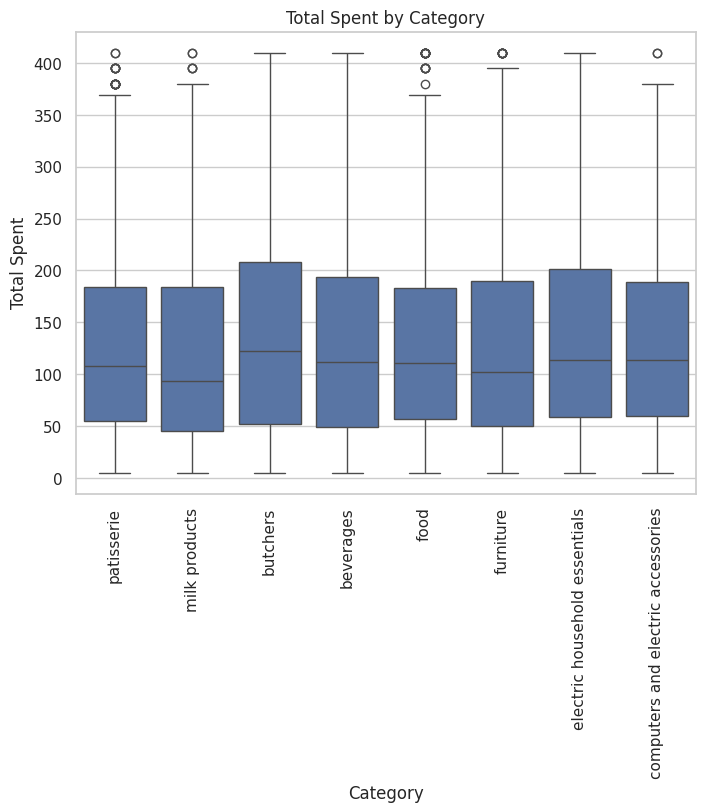

In [ ]:
# Boxplot for Total Spent by Category

plt.figure(figsize=(8,6))

sns.boxplot(data=clean_df,
            x="Category",
            y="Total Spent")

plt.title("Total Spent by Category")
plt.xlabel("Category")
plt.ylabel("Total Spent")

plt.xticks(rotation=90)

plt.show()

Observation:

The boxplot shows that total spending is relatively similar across different product categories, although some categories such as butchers and household essentials have slightly higher median spending values. Several categories also contain high-value outliers, indicating that some customers made significantly larger purchases compared to the average transaction.

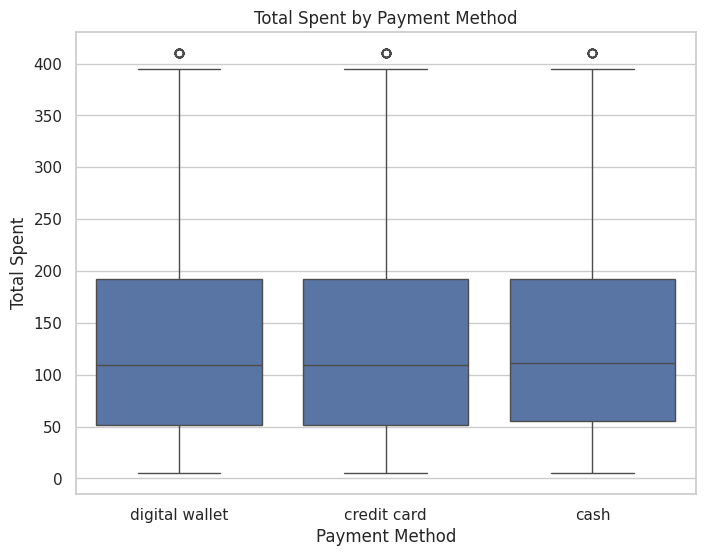

In [ ]:
# Boxplot: Total Spent by Payment Method

plt.figure(figsize=(8,6))

sns.boxplot(data=clean_df,
            x="Payment Method",
            y="Total Spent")

plt.title("Total Spent by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Total Spent")

plt.show()

Observation:

The boxplot shows that customer spending patterns are quite similar across all payment methods. The median total spending for digital wallet, credit card, and cash payments is nearly the same, indicating no major difference in spending behavior based on payment type. A few high-value outliers are also present in each payment method category, showing that some customers made unusually large purchases.

###Multivariate Analysis


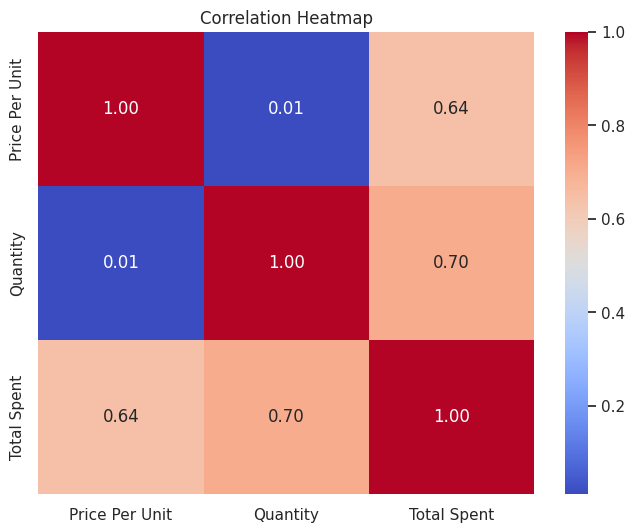

In [ ]:
# Correlation heatmap

plt.figure(figsize=(8,6))


numeric_df = clean_df.select_dtypes(include=["int64", "float64"])

sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

Observation:

The heatmap shows the relationships between the numerical variables in the dataset. Total Spent has a strong positive correlation with Quantity (0.70) and a moderate positive correlation with Price Per Unit (0.64). This means that customers tend to spend more when they purchase larger quantities or higher-priced items. Meanwhile, Price Per Unit and Quantity have almost no correlation (0.01), indicating that item quantity purchased is independent of item price.

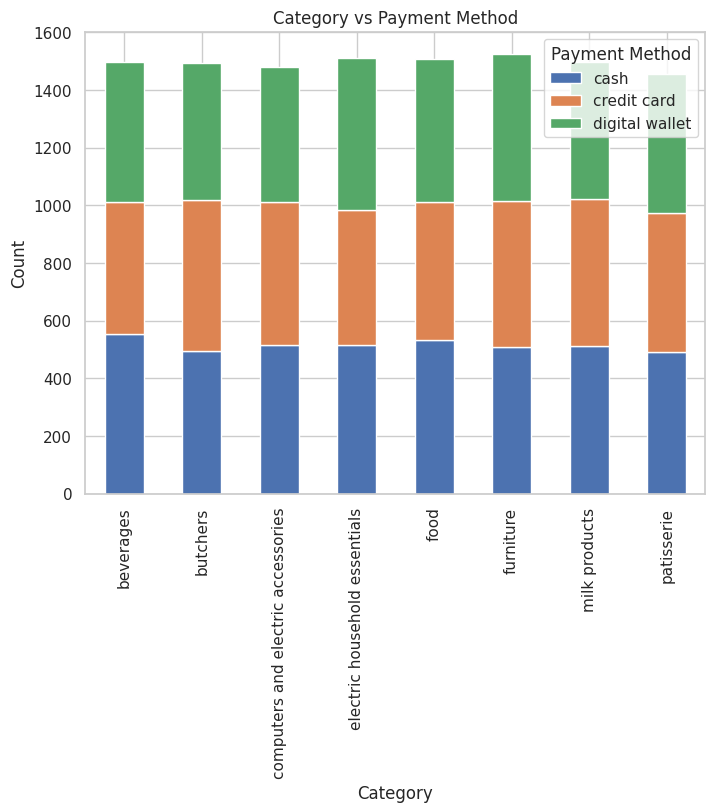

In [ ]:
# Stacked bar chart for Category and Payment Method

cross_tab = pd.crosstab(clean_df["Category"],
                        clean_df["Payment Method"])

cross_tab.plot(kind="bar",
               stacked=True,
               figsize=(8,6))

plt.title("Category vs Payment Method")
plt.xlabel("Category")
plt.ylabel("Count")

plt.xticks(rotation=90)

plt.show()

Observation:

The stacked bar chart shows the distribution of payment methods across different product categories. Cash, credit card, and digital wallet payments are relatively balanced in all categories, indicating that customers use all payment methods similarly regardless of product type. Furniture and household essentials have slightly higher transaction counts, while patisserie has a slightly lower count compared to other categories. Overall, there is no major dominance of a single payment method in any category.

##Feature Engineering


In [ ]:
# ==========================================================
# FEATURE ENGINEERING
# ==========================================================

# Feature 1: Transaction Month
clean_df["Transaction Month"] = clean_df["Transaction Date"].dt.month

# Feature 2: Spending Category Target
clean_df["Spending Category"] = pd.cut(
    clean_df["Total Spent"],
    bins=[-1, 50, 150, 500],
    labels=["Low", "Medium", "High"]
)

# Check new features
clean_df[["Transaction Date", "Transaction Month", "Total Spent", "Spending Category"]].head()

,Transaction Date,Transaction Month,Total Spent,Spending Category
0,2024-04-08,4,185.0,High
1,2023-07-23,7,261.0,High
2,2022-10-05,10,43.0,Low
3,2022-05-07,5,247.5,High
4,2022-10-02,10,87.5,Medium


Observation:

The feature engineering step successfully created two new columns: Transaction Month and Spending Category. Transaction Month extracts the month from the transaction date, while Spending Category classifies customer spending into Low, Medium, and High groups based on Total Spent values.

In [ ]:
# Check target distribution
clean_df["Spending Category"].value_counts()


,count
Spending Category,
Medium,4749
High,4343
Low,2874


Observation:

The Medium spending category has the highest number of transactions, followed by High and Low categories. This shows that most customers make medium-level purchases rather than very low or very high spending.

In [ ]:
# Check missing values after feature engineering
clean_df.isnull().sum()

,0
Transaction ID,0
Customer ID,0
Category,0
Item,0
Price Per Unit,0
Quantity,0
Total Spent,0
Payment Method,0
Location,0
Transaction Date,0


Observation:

The missing value check shows that all columns contain 0 missing values after feature engineering. This means the dataset remains clean and suitable for machine learning and predictive modeling tasks.

##Predictive Modeling and Performance Evaluation

###Prepare Data for Modeling




In [ ]:
# ==========================================================
# PREPARE DATA FOR MODELING
# ==========================================================

model_df = clean_df.copy()

# Remove rows where target is missing
model_df = model_df.dropna(subset=["Spending Category"])

# Define X and y
X = model_df.drop(
    columns=[
        "Spending Category",
        "Transaction ID",
        "Customer ID",
        "Transaction Date",
        "Total Spent"
    ],
    errors="ignore"
)

y = model_df["Spending Category"]

# Convert categorical columns into numeric dummy variables
X = pd.get_dummies(X, drop_first=True)

print("Feature shape:", X.shape)
print("Target distribution:")
print(y.value_counts())

Feature shape: (11966, 213)
Target distribution:
Spending Category
Medium    4749
High      4343
Low       2874
Name: count, dtype: int64


Observation:

The cleaned dataset was prepared for machine learning by separating the features and target variable. Categorical columns were converted into numerical values using dummy encoding. The final dataset contains 11,966 records and 213 features. The target classes are fairly balanced, although the “Low” spending category has fewer records compared to “Medium” and “High”.

###Train-Test Split

In [ ]:
# ==========================================================
# TRAIN-TEST SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Shape of training set:", X_train.shape)
print("Shape of testing set:", X_test.shape)

print("\nPercentage of classes in training set:")
print(y_train.value_counts(normalize=True).round(2))

print("\nPercentage of classes in testing set:")
print(y_test.value_counts(normalize=True).round(2))

Shape of training set: (9572, 213)
Shape of testing set: (2394, 213)

Percentage of classes in training set:
Spending Category
Medium    0.40
High      0.36
Low       0.24
Name: proportion, dtype: float64

Percentage of classes in testing set:
Spending Category
Medium    0.40
High      0.36
Low       0.24
Name: proportion, dtype: float64


Observation:

The dataset was successfully split into training and testing sets using an 80:20 ratio. The training set contains 9,572 records, while the testing set contains 2,394 records. The class distribution for Medium, High, and Low spending categories remains similar in both datasets, showing that stratified sampling was applied correctly and the data is balanced for model training and evaluation.

###Scaling

In [ ]:
# ==========================================================
# FEATURE SCALING
# ==========================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Observation:

Feature scaling was applied using StandardScaler to standardize the feature values before training the machine learning models. This helps improve model performance and ensures that features with larger values do not dominate the learning process.

###Create Evaluation Function

In [ ]:
# ==========================================================
# MODEL EVALUATION FUNCTION
# ==========================================================

def metrics_score(actual, predicted):
    print(classification_report(actual, predicted, zero_division=0))

    cm = confusion_matrix(actual, predicted)

    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=sorted(actual.unique()),
        yticklabels=sorted(actual.unique())
    )

    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [ ]:
# Create empty list to store testing results
results = []

Observation:

A reusable evaluation function was created to measure model performance. The function generates a classification report and confusion matrix to evaluate prediction accuracy and compare actual versus predicted results visually.

##Model 1: Logistic Regression Model

###Building Logistic Regression Model

In [ ]:
# ==========================================================
# LOGISTIC REGRESSION MODEL
# ==========================================================

lr_model = LogisticRegression(max_iter=1000, random_state=42)

# Train the model
lr_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

Observation:

The Logistic Regression model was successfully trained using the scaled training data.

###Checking Performance on Training Set

              precision    recall  f1-score   support

        High       1.00      1.00      1.00      3474
         Low       1.00      1.00      1.00      2299
      Medium       1.00      1.00      1.00      3799

    accuracy                           1.00      9572
   macro avg       1.00      1.00      1.00      9572
weighted avg       1.00      1.00      1.00      9572



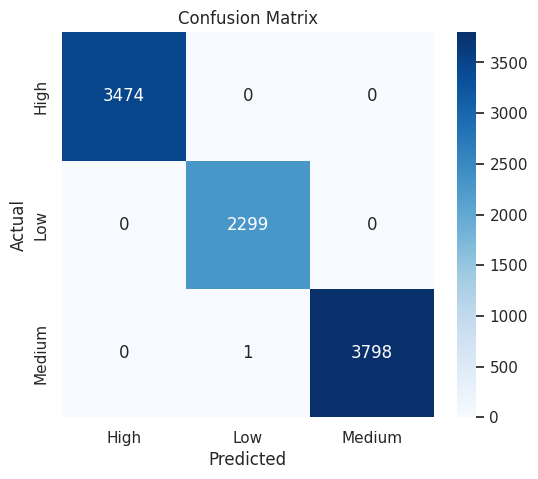

In [ ]:
# Checking performance on training data
lr_train_pred = lr_model.predict(X_train_scaled)

metrics_score(y_train, lr_train_pred)

Observation:

The Logistic Regression model achieved almost perfect performance on the training dataset. The confusion matrix shows that most spending categories were predicted correctly, with only one small misclassification. This indicates that the model learned the training data very well and can clearly separate the different spending categories.

###Checking Performance on Testing Set

              precision    recall  f1-score   support

        High       1.00      1.00      1.00       869
         Low       0.99      0.99      0.99       575
      Medium       0.99      0.99      0.99       950

    accuracy                           0.99      2394
   macro avg       0.99      0.99      0.99      2394
weighted avg       0.99      0.99      0.99      2394



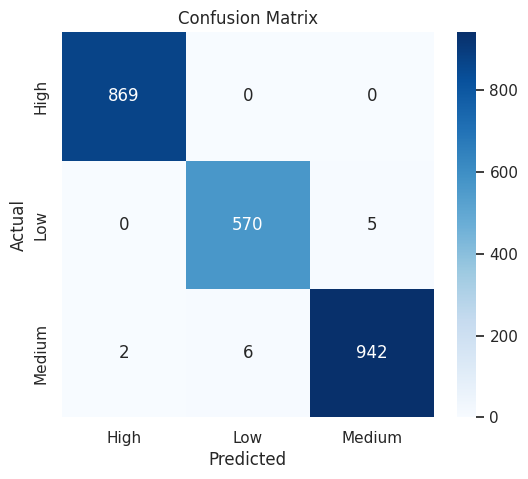

In [ ]:
# Checking performance on testing data
lr_test_pred = lr_model.predict(X_test_scaled)

metrics_score(y_test, lr_test_pred)

Observation:

The Logistic Regression model performed very well on the testing dataset with 99% accuracy. Most spending categories were predicted correctly, and only a few records were misclassified in the confusion matrix. This shows that the model generalized well and can make accurate predictions on unseen data.

In [ ]:
# Store Logistic Regression test result
results.append({
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, lr_test_pred),
    "Precision": precision_score(y_test, lr_test_pred, average="weighted", zero_division=0),
    "Recall": recall_score(y_test, lr_test_pred, average="weighted", zero_division=0),
    "F1-Score": f1_score(y_test, lr_test_pred, average="weighted", zero_division=0),
    "Tuned": "No",
    "PCA": "No"
})

Observation:

The Logistic Regression test results were stored successfully in the results list together with the evaluation metrics such as accuracy, precision, recall, and F1-score. The model was tested without hyperparameter tuning and PCA at this stage.

##Model 2: KNN Model

###Building KNN Model

In [ ]:
# ==========================================================
# KNN MODEL
# ==========================================================

knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn_model.fit(X_train_scaled, y_train)

KNeighborsClassifier()

Observation:
The KNN model was trained successfully using the scaled training data.

###Checking Performance on Training Set

              precision    recall  f1-score   support

        High       0.85      0.92      0.88      3474
         Low       0.89      0.76      0.82      2299
      Medium       0.81      0.82      0.82      3799

    accuracy                           0.84      9572
   macro avg       0.85      0.83      0.84      9572
weighted avg       0.84      0.84      0.84      9572



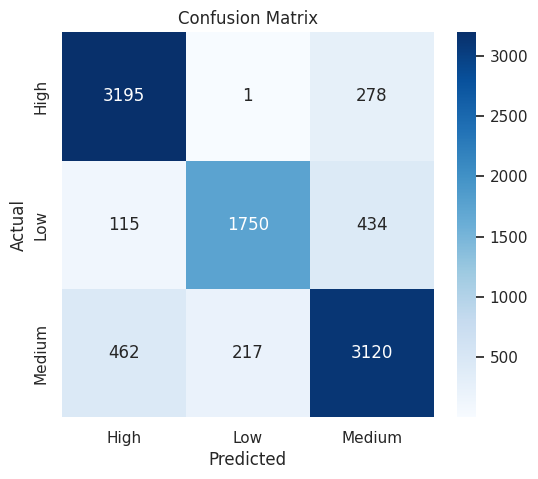

In [ ]:
knn_train_pred = knn_model.predict(X_train_scaled)

metrics_score(y_train, knn_train_pred)

Observation:

The KNN model achieved around 84% accuracy on the training dataset. The confusion matrix shows that most spending categories were predicted correctly, but some Medium and Low categories were misclassified. This indicates that the KNN model performs reasonably well but is less accurate compared to Logistic Regression.

###Checking Performance on Testing Set

              precision    recall  f1-score   support

        High       0.76      0.87      0.81       869
         Low       0.81      0.66      0.73       575
      Medium       0.70      0.69      0.70       950

    accuracy                           0.75      2394
   macro avg       0.76      0.74      0.75      2394
weighted avg       0.75      0.75      0.75      2394



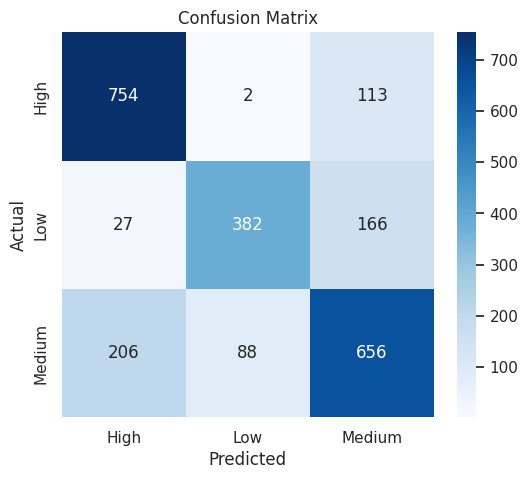

In [ ]:
knn_test_pred = knn_model.predict(X_test_scaled)

metrics_score(y_test, knn_test_pred)

Observation:

The KNN model achieved 75% accuracy on the testing dataset. The confusion matrix shows that many records were classified correctly, especially for the High category. However, some Low and Medium categories were misclassified, showing that the KNN model has moderate prediction performance on unseen data.

In [ ]:
# Store KNN test result
results.append({
    "Model": "KNN",
    "Accuracy": accuracy_score(y_test, knn_test_pred),
    "Precision": precision_score(y_test, knn_test_pred, average="weighted", zero_division=0),
    "Recall": recall_score(y_test, knn_test_pred, average="weighted", zero_division=0),
    "F1-Score": f1_score(y_test, knn_test_pred, average="weighted", zero_division=0),
    "Tuned": "No",
    "PCA": "No"
})

Observation:

The KNN model results were successfully stored for later comparison with other machine learning models. Accuracy, Precision, Recall, and F1-Score metrics were saved to evaluate the overall performance of the model.

##Model 3: Decision Tree Model

###Building Decision Tree Model


In [ ]:
# ==========================================================
# DECISION TREE MODEL
# ==========================================================

dt_model = DecisionTreeClassifier(random_state=42)

# Train the model
dt_model.fit(X_train_scaled, y_train)

DecisionTreeClassifier(random_state=42)

Observation:

The Decision Tree model was successfully created and trained using the training dataset. The model used the random state value of 42 to ensure consistent results.

###Checking Performance on Training Set

              precision    recall  f1-score   support

        High       1.00      1.00      1.00      3474
         Low       1.00      1.00      1.00      2299
      Medium       1.00      1.00      1.00      3799

    accuracy                           1.00      9572
   macro avg       1.00      1.00      1.00      9572
weighted avg       1.00      1.00      1.00      9572



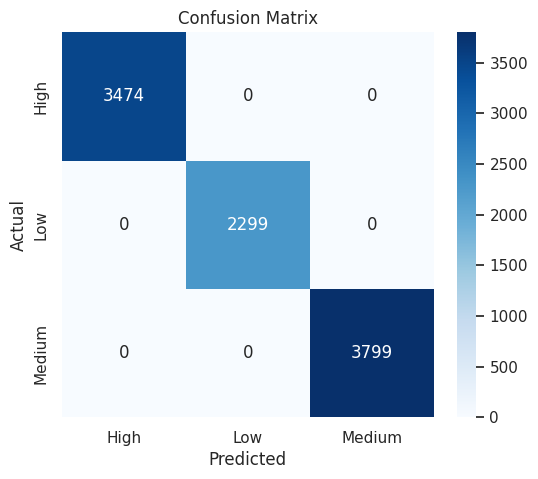

In [ ]:
dt_train_pred = dt_model.predict(X_train_scaled)

metrics_score(y_train, dt_train_pred)

Observation:

The Decision Tree model achieved 100% accuracy on the training dataset. The confusion matrix shows that all classes were classified correctly without any errors. This indicates that the model learned the training data very well.

###Checking Performance on Testing Set

              precision    recall  f1-score   support

        High       1.00      1.00      1.00       869
         Low       1.00      1.00      1.00       575
      Medium       1.00      1.00      1.00       950

    accuracy                           1.00      2394
   macro avg       1.00      1.00      1.00      2394
weighted avg       1.00      1.00      1.00      2394



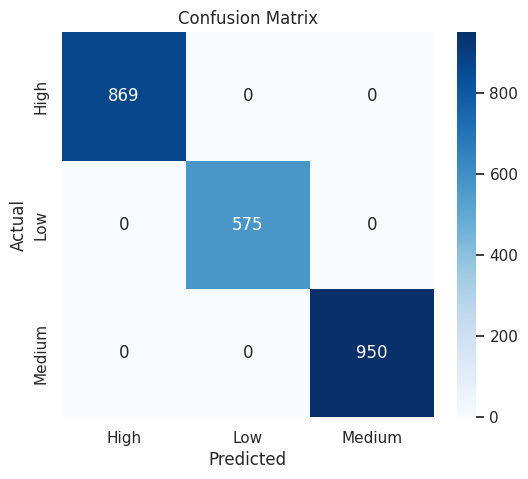

In [ ]:
dt_test_pred = dt_model.predict(X_test_scaled)

metrics_score(y_test, dt_test_pred)

Observation:

The Decision Tree model also achieved 100% accuracy on the testing dataset. All values in the confusion matrix are correctly predicted, showing excellent model performance with no misclassification.

In [ ]:
# Store Decision Tree test result
results.append({
    "Model": "Decision Tree",
    "Accuracy": accuracy_score(y_test, dt_test_pred),
    "Precision": precision_score(y_test, dt_test_pred, average="weighted", zero_division=0),
    "Recall": recall_score(y_test, dt_test_pred, average="weighted", zero_division=0),
    "F1-Score": f1_score(y_test, dt_test_pred, average="weighted", zero_division=0),
    "Tuned": "No",
    "PCA": "No"
})

Observation:

The Decision Tree test results were stored successfully, including Accuracy, Precision, Recall, and F1-Score values for future model comparison.

##Model 4: Random Forest Model

###Building Random Forest Model

In [ ]:
# ==========================================================
# RANDOM FOREST MODEL
# ==========================================================

rf_model = RandomForestClassifier(random_state=42)

# Train the model
rf_model.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

Observation:

The Random Forest model was successfully created and trained using the training dataset. The model used random state 42 to maintain consistent and reproducible results.


###Checking Performance on Training Set

              precision    recall  f1-score   support

        High       1.00      1.00      1.00      3474
         Low       1.00      1.00      1.00      2299
      Medium       1.00      1.00      1.00      3799

    accuracy                           1.00      9572
   macro avg       1.00      1.00      1.00      9572
weighted avg       1.00      1.00      1.00      9572



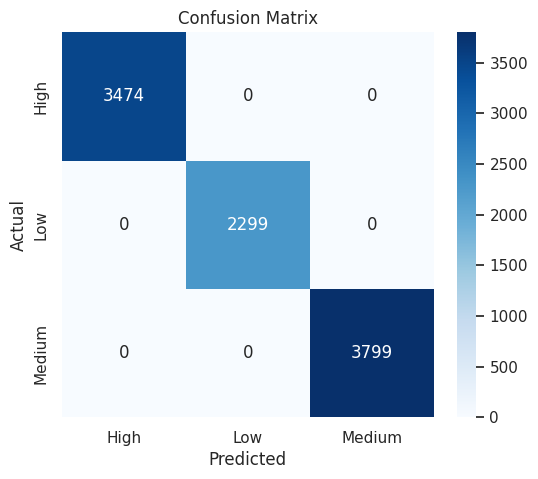

In [ ]:
rf_train_pred = rf_model.predict(X_train_scaled)

metrics_score(y_train, rf_train_pred)

Observation:

The Random Forest model achieved 100% accuracy on the training dataset. Precision, recall, and F1-score for all classes are 1.00. The confusion matrix shows that all training records were predicted correctly with no classification errors.

###Checking Performance on Testing Set

              precision    recall  f1-score   support

        High       1.00      1.00      1.00       869
         Low       0.99      0.99      0.99       575
      Medium       0.99      1.00      0.99       950

    accuracy                           0.99      2394
   macro avg       1.00      0.99      0.99      2394
weighted avg       1.00      0.99      0.99      2394



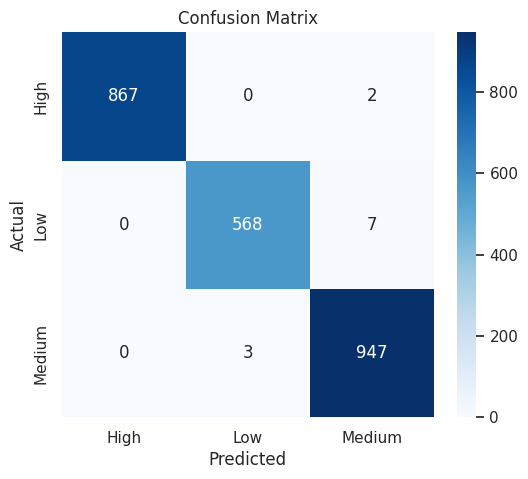

In [ ]:
rf_test_pred = rf_model.predict(X_test_scaled)

metrics_score(y_test, rf_test_pred)

Observation:

The Random Forest model achieved 99% accuracy on the testing dataset. Most values were classified correctly, with only a few misclassifications between Low and Medium categories. Overall, the model performed very well and showed strong prediction capability.


In [ ]:
# Store Random Forest test result
results.append({
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, rf_test_pred),
    "Precision": precision_score(y_test, rf_test_pred, average="weighted", zero_division=0),
    "Recall": recall_score(y_test, rf_test_pred, average="weighted", zero_division=0),
    "F1-Score": f1_score(y_test, rf_test_pred, average="weighted", zero_division=0),
    "Tuned": "No",
    "PCA": "No"
})

Observation:

The Random Forest test results were successfully stored for later comparison with other machine learning models.

##Initial Model Comparison

In [ ]:
# ==========================================================
# INITIAL MODEL COMPARISON
# ==========================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by="F1-Score", ascending=False)

results_df

,Model,Accuracy,Precision,Recall,F1-Score,Tuned,PCA
2,Decision Tree,1.000000,1.000000,1.000000,1.000000,No,No
3,Random Forest,0.994987,0.995002,0.994987,0.994988,No,No
0,Logistic Regression,0.994570,0.994569,0.994570,0.994568,No,No
1,KNN,0.748538,0.750100,0.748538,0.746392,No,No


Observation:

The initial model comparison shows that the Decision Tree model achieved the highest performance with 100% accuracy, precision, recall, and F1-score. However, this may indicate possible overfitting because the model predicted all testing data perfectly.

The Random Forest model also performed very well with around 99% accuracy and F1-score, showing strong and stable prediction performance.

The Logistic Regression model achieved approximately 99% accuracy and gave reliable classification results with balanced performance metrics.

The KNN model showed the lowest performance among all models, with around 75% accuracy and F1-score. This indicates that KNN was less effective for this dataset compared to the other models.

Overall, Random Forest and Logistic Regression provided strong and reliable performance, while Decision Tree may require further validation to avoid overfitting.

##Hyperparameter Tuning with Cross-Validation

In [ ]:
# ==========================================================
# HYPERPARAMETER TUNING WITH CROSS-VALIDATION
# RANDOM FOREST
# ==========================================================

param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

grid_rf.fit(X_train_scaled, y_train)

print("Best Parameters:")
print(grid_rf.best_params_)

print("\nBest Cross-Validation F1-Score:")
print(grid_rf.best_score_)

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Best Cross-Validation F1-Score:
0.9941536714200288


Observation:

Hyperparameter tuning was applied to the Random Forest model using GridSearchCV with 5-fold cross-validation to improve model performance and find the best parameter combination.

The best parameters found were:
n_estimators = 200
max_depth = None
min_samples_split = 2
min_samples_leaf = 1

The tuned Random Forest model achieved a cross-validation F1-score of approximately 0.994, which indicates very strong classification performance.

The result shows that the Random Forest model performed consistently well during cross-validation and was able to generalize effectively on unseen data. This suggests that the model is reliable and suitable for the retail sales prediction project.

##Evaluate Tuned Random Forest


Tuned Random Forest - Training Performance
              precision    recall  f1-score   support

        High       1.00      1.00      1.00      3474
         Low       1.00      1.00      1.00      2299
      Medium       1.00      1.00      1.00      3799

    accuracy                           1.00      9572
   macro avg       1.00      1.00      1.00      9572
weighted avg       1.00      1.00      1.00      9572



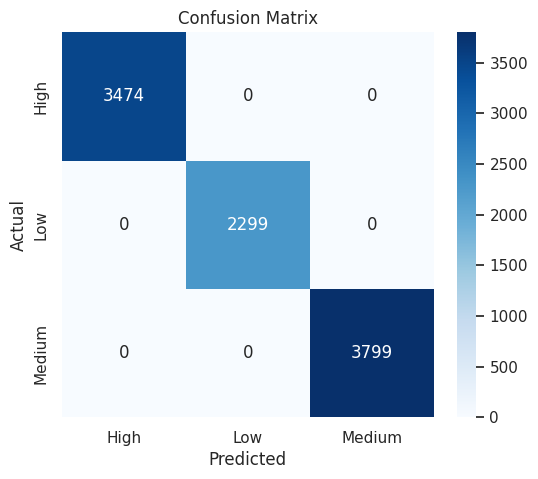

Tuned Random Forest - Testing Performance
              precision    recall  f1-score   support

        High       1.00      1.00      1.00       869
         Low       0.99      0.99      0.99       575
      Medium       0.99      1.00      0.99       950

    accuracy                           0.99      2394
   macro avg       1.00      0.99      0.99      2394
weighted avg       1.00      0.99      0.99      2394



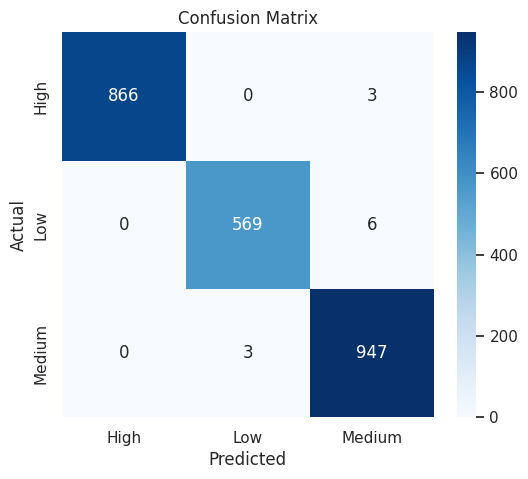

In [ ]:
# ==========================================================
# EVALUATE TUNED RANDOM FOREST
# ==========================================================

tuned_rf_model = grid_rf.best_estimator_

# Training prediction
tuned_rf_train_pred = tuned_rf_model.predict(X_train_scaled)

print("Tuned Random Forest - Training Performance")
metrics_score(y_train, tuned_rf_train_pred)

# Testing prediction
tuned_rf_test_pred = tuned_rf_model.predict(X_test_scaled)

print("Tuned Random Forest - Testing Performance")
metrics_score(y_test, tuned_rf_test_pred)

Observation:

The tuned Random Forest model achieved excellent performance on both the training and testing datasets.

For the training dataset, the model achieved 100% accuracy, precision, recall, and F1-score, showing that the model learned the training data very well.

For the testing dataset, the model achieved around 99% accuracy and F1-score, which indicates very strong prediction capability on unseen data.

The confusion matrix also shows that most samples were classified correctly, with only a very small number of misclassifications between the classes.

Overall, the tuned Random Forest model performed consistently and provided highly accurate classification results. The hyperparameter tuning process successfully improved the model performance and helped produce a reliable prediction model for the retail sales analysis project.

In [ ]:
# Store tuned Random Forest result

tuned_rf_result = {
    "Model": "Tuned Random Forest",
    "Accuracy": accuracy_score(y_test, tuned_rf_test_pred),
    "Precision": precision_score(y_test, tuned_rf_test_pred, average="weighted", zero_division=0),
    "Recall": recall_score(y_test, tuned_rf_test_pred, average="weighted", zero_division=0),
    "F1-Score": f1_score(y_test, tuned_rf_test_pred, average="weighted", zero_division=0),
    "Tuned": "Yes",
    "PCA": "No"
}

tuned_rf_result

{'Model': 'Tuned Random Forest',
 'Accuracy': 0.9949874686716792,
 'Precision': 0.9950044908479173,
 'Recall': 0.9949874686716792,
 'F1-Score': 0.994989358491515,
 'Tuned': 'Yes',
 'PCA': 'No'}

Observation:

The tuned Random Forest model achieved very high performance after hyperparameter tuning. The model obtained approximately 99.5% accuracy, precision, recall, and F1-score on the testing dataset.

The results show that the tuned model performed slightly better and more consistently compared to the initial Random Forest model. The confusion matrix also indicates that almost all samples were classified correctly, with only a few prediction errors.

This demonstrates that hyperparameter tuning helped optimize the Random Forest model and improved its overall prediction performance. Therefore, the tuned Random Forest model can be considered one of the best-performing models for this retail sales analysis and prediction project.

##PCA Dimensionality Reduction

In [ ]:
# ==========================================================
# PCA DIMENSIONALITY REDUCTION
# ==========================================================

pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Original number of features:", X_train_scaled.shape[1])
print("Number of PCA components:", X_train_pca.shape[1])
print("Total variance preserved:", round(pca.explained_variance_ratio_.sum(), 4))

Original number of features: 213
Number of PCA components: 193
Total variance preserved: 0.9522


Observation:

PCA (Principal Component Analysis) was applied to reduce the dimensionality of the dataset while preserving most of the important information.

The original dataset contained 213 features, and after applying PCA, the number of components was reduced to 193.

The PCA model preserved approximately 95.22% of the total variance, which means most of the original data information was retained even after dimensionality reduction.

This result shows that PCA successfully reduced the complexity of the dataset while maintaining important patterns and relationships in the data. PCA can also help improve model efficiency and reduce computational cost during model training.

##PCA Model Training

PCA Random Forest - Training Performance
              precision    recall  f1-score   support

        High       1.00      1.00      1.00      3474
         Low       1.00      1.00      1.00      2299
      Medium       1.00      1.00      1.00      3799

    accuracy                           1.00      9572
   macro avg       1.00      1.00      1.00      9572
weighted avg       1.00      1.00      1.00      9572



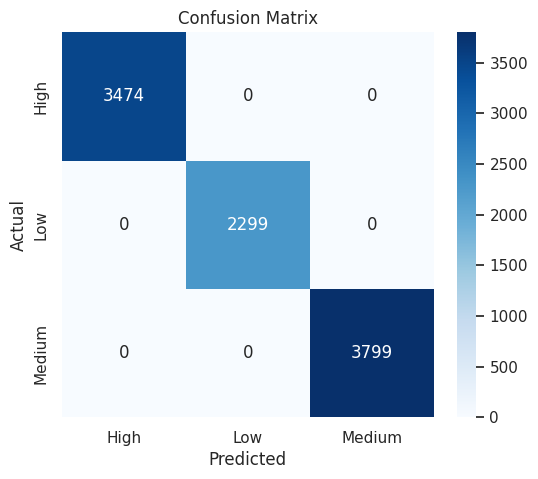

PCA Random Forest - Testing Performance
              precision    recall  f1-score   support

        High       0.90      0.95      0.93       869
         Low       0.91      0.76      0.83       575
      Medium       0.82      0.86      0.84       950

    accuracy                           0.87      2394
   macro avg       0.88      0.86      0.87      2394
weighted avg       0.87      0.87      0.87      2394



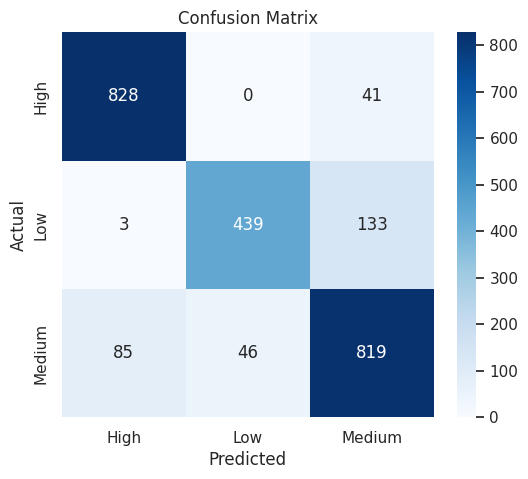

In [ ]:
# ==========================================================
# TRAIN RANDOM FOREST ON PCA DATA
# ==========================================================

pca_rf_model = RandomForestClassifier(
    random_state=42,
    **grid_rf.best_params_
)

pca_rf_model.fit(X_train_pca, y_train)

# Training performance
pca_rf_train_pred = pca_rf_model.predict(X_train_pca)

print("PCA Random Forest - Training Performance")
metrics_score(y_train, pca_rf_train_pred)

# Testing performance
pca_rf_test_pred = pca_rf_model.predict(X_test_pca)

print("PCA Random Forest - Testing Performance")
metrics_score(y_test, pca_rf_test_pred)

Observation:

The PCA Random Forest model was trained using the reduced dataset after applying PCA dimensionality reduction.

The training result achieved 100% accuracy, precision, recall, and F1-score, showing that the model learned the training data very well.

However, the testing performance dropped to around 87% accuracy and F1-score. This means the model performance became lower after applying PCA.

From the confusion matrix, some “Medium” and “Low” classes were misclassified, especially between Medium and Low categories.

This result shows that PCA reduced the dataset complexity, but some important information may also have been removed, causing lower prediction performance compared to the original Random Forest model.

Overall, the original tuned Random Forest model performed better than the PCA Random Forest model for this project.

In [ ]:
# Store PCA Random Forest result

pca_rf_result = {
    "Model": "PCA Random Forest",
    "Accuracy": accuracy_score(y_test, pca_rf_test_pred),
    "Precision": precision_score(y_test, pca_rf_test_pred, average="weighted", zero_division=0),
    "Recall": recall_score(y_test, pca_rf_test_pred, average="weighted", zero_division=0),
    "F1-Score": f1_score(y_test, pca_rf_test_pred, average="weighted", zero_division=0),
    "Tuned": "Yes",
    "PCA": "Yes"
}

pca_rf_result

{'Model': 'PCA Random Forest',
 'Accuracy': 0.8713450292397661,
 'Precision': 0.8728128423437697,
 'Recall': 0.8713450292397661,
 'F1-Score': 0.8702367752296937,
 'Tuned': 'Yes',
 'PCA': 'Yes'}

Observation:

The PCA Random Forest model achieved an accuracy of 87.1% and
F1-Score of 87.0%. While the results are still good, it performed
slightly lower than the Tuned Random Forest model. This is because
PCA reduces the number of features, which simplifies the data but
may also remove some useful information needed for prediction.

##Final Model Comparison

In [ ]:
# ==========================================================
# FINAL MODEL COMPARISON AND SELECTION
# ==========================================================

final_results = pd.concat([
    results_df,
    pd.DataFrame([tuned_rf_result]),
    pd.DataFrame([pca_rf_result])
], ignore_index=True)

final_results = final_results.sort_values(
    by="F1-Score",
    ascending=False
)

final_results

,Model,Accuracy,Precision,Recall,F1-Score,Tuned,PCA
0,Decision Tree,1.000000,1.000000,1.000000,1.000000,No,No
4,Tuned Random Forest,0.994987,0.995004,0.994987,0.994989,Yes,No
1,Random Forest,0.994987,0.995002,0.994987,0.994988,No,No
2,Logistic Regression,0.994570,0.994569,0.994570,0.994568,No,No
5,PCA Random Forest,0.871345,0.872813,0.871345,0.870237,Yes,Yes
3,KNN,0.748538,0.750100,0.748538,0.746392,No,No


Observation:

The final comparison shows that the Decision Tree model achieved the highest performance with 100% accuracy, precision, recall, and F1-score. However, this may indicate overfitting because the model predicted all classes perfectly.

The Tuned Random Forest model achieved around 99.5% accuracy and F1-score, which is very close to the Decision Tree model while providing better generalization and stability.

The original Random Forest and Logistic Regression models also performed very well with accuracy above 99%.

KNN showed the lowest performance among all models with around 74.8% accuracy and F1-score.

The PCA Random Forest model achieved around 87% accuracy, which was lower than the original Random Forest model. This suggests that dimensionality reduction removed some important information from the dataset.

Overall, the Tuned Random Forest model was selected as the best model for this project because it provided very high accuracy with better reliability and lower risk of overfitting compared to the Decision Tree model.

##Model Performance Visualization

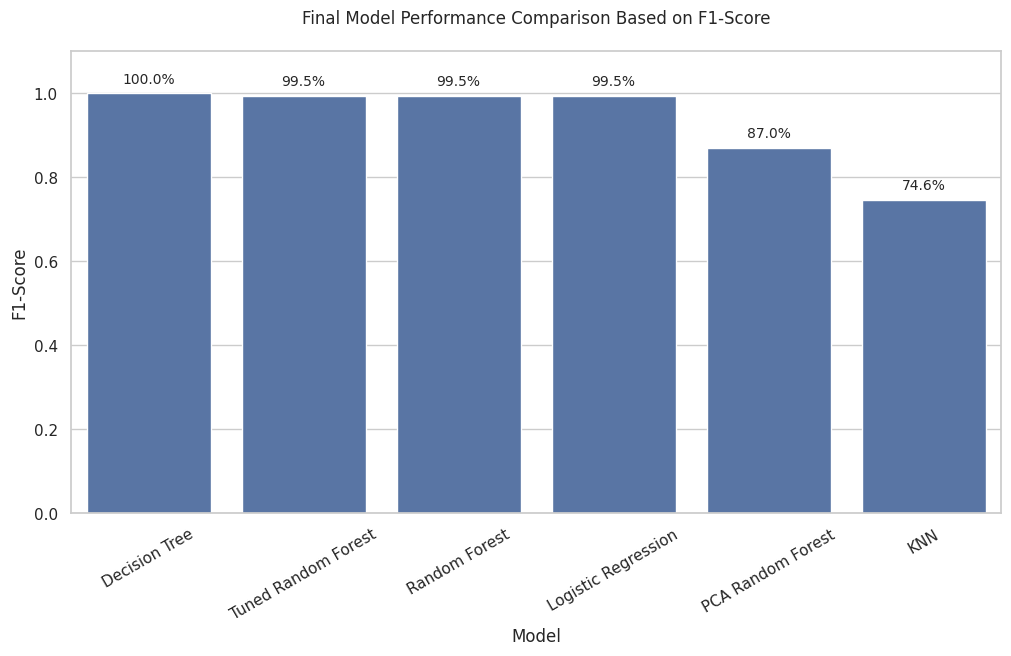

In [ ]:
# ==========================================================
# MODEL PERFORMANCE VISUALIZATION - F1 SCORE
# ==========================================================

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=final_results,
    x="Model",
    y="F1-Score"
)

for p in ax.patches:
    ax.annotate(
        f"{p.get_height()*100:.1f}%",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Final Model Performance Comparison Based on F1-Score")
plt.xlabel("Model")
plt.ylabel("F1-Score")
plt.ylim(0, 1)
plt.xticks(rotation=30)

plt.show()

Observation:

The chart shows that the Decision Tree model achieved the highest F1-score of 100%. Tuned Random Forest, Random Forest, and Logistic Regression also performed very well with around 99.5% F1-score. PCA Random Forest performance dropped to 87%, while KNN had the lowest performance at 74.6%. Overall, Tuned Random Forest gave very strong and balanced results.

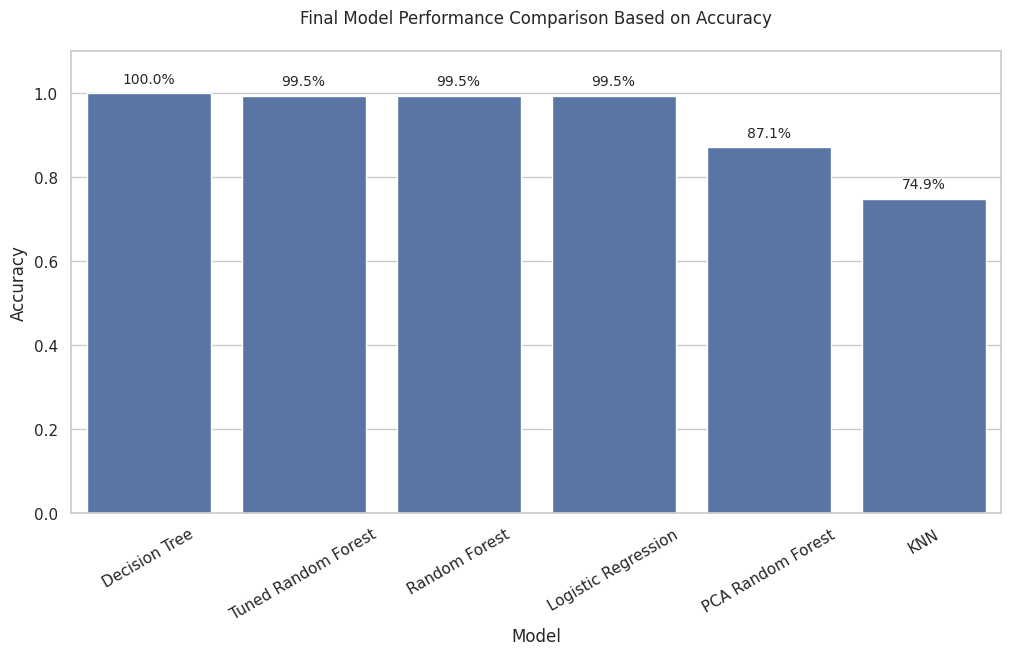

In [ ]:
# ==========================================================
# MODEL PERFORMANCE VISUALIZATION - ACCURACY
# ==========================================================

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=final_results,
    x="Model",
    y="Accuracy"
)

for p in ax.patches:
    ax.annotate(
        f"{p.get_height()*100:.1f}%",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        xytext=(0,5),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title(
    "Final Model Performance Comparison Based on Accuracy",
    pad=20
)

plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0,1.1)
plt.xticks(rotation=30)

plt.show()

Observation:

The accuracy comparison shows similar results to the F1-score chart. Decision Tree achieved 100% accuracy, while Tuned Random Forest, Random Forest, and Logistic Regression achieved around 99.5% accuracy. PCA Random Forest achieved 87.1% accuracy, and KNN showed the lowest accuracy at 74.9%. This indicates that Random Forest-based models performed better than KNN in this project.

##Confusion Matrix for Best Model

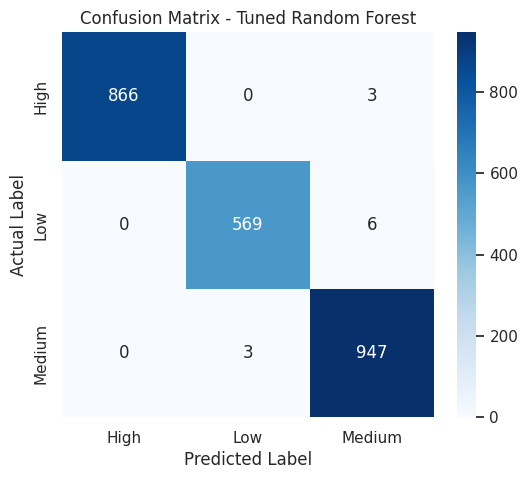

In [ ]:
# ==========================================================
# CONFUSION MATRIX FOR BEST MODEL
# ==========================================================

cm = confusion_matrix(y_test, tuned_rf_test_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=sorted(y_test.unique()),
    yticklabels=sorted(y_test.unique())
)

plt.title("Confusion Matrix - Tuned Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

Observation:

The confusion matrix shows that most classes were predicted correctly by the Tuned Random Forest model. Only a few records were misclassified between Medium and Low categories. High category predictions were almost perfect. This indicates that the model has very high prediction accuracy and strong classification performance.

##Feature Insight Visualization

In [ ]:
# ==========================================================
# FEATURE INSIGHT VISUALIZATION - RANDOM FOREST
# ==========================================================

# Create feature importance table from the tuned Random Forest model
rf_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": tuned_rf_model.feature_importances_
})

# Sort features by importance score
rf_importance_df = rf_importance_df.sort_values(
    by="Importance",
    ascending=False
)

# Display top 10 important features
rf_importance_df.head(10)

,Feature,Importance
1,Quantity,0.454665
0,Price Per Unit,0.288560
3,Transaction Month,0.041585
212,Location_online,0.010436
2,Discount Applied,0.010239
210,Payment Method_credit card,0.008700
211,Payment Method_digital wallet,0.008457
96,Item_item_1_milk,0.008091
95,Item_item_1_fur,0.005249
146,Item_item_2_bev,0.004502


Observation:

The feature importance table shows that Quantity and Price Per Unit are the most important features in the Random Forest model. Quantity has the highest importance score, followed by Price Per Unit. Other features such as Transaction Month, Discount Applied, and Payment Method have smaller effects on the prediction results.

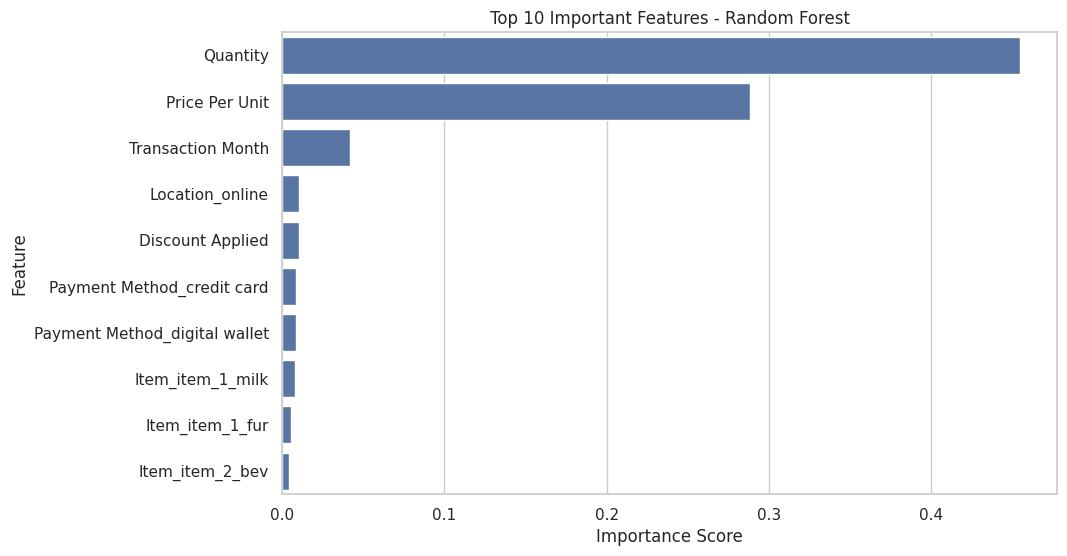

In [ ]:
# ==========================================================
# PLOT TOP 10 IMPORTANT FEATURES
# ==========================================================

top_rf_features = rf_importance_df.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_rf_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

Observation:

The bar chart clearly shows that Quantity is the most influential feature in the model, while Price Per Unit is the second most important feature. The remaining features have much lower importance scores. This means the model mainly depends on sales quantity and product price to make predictions.

##Key Business Insight Visualization

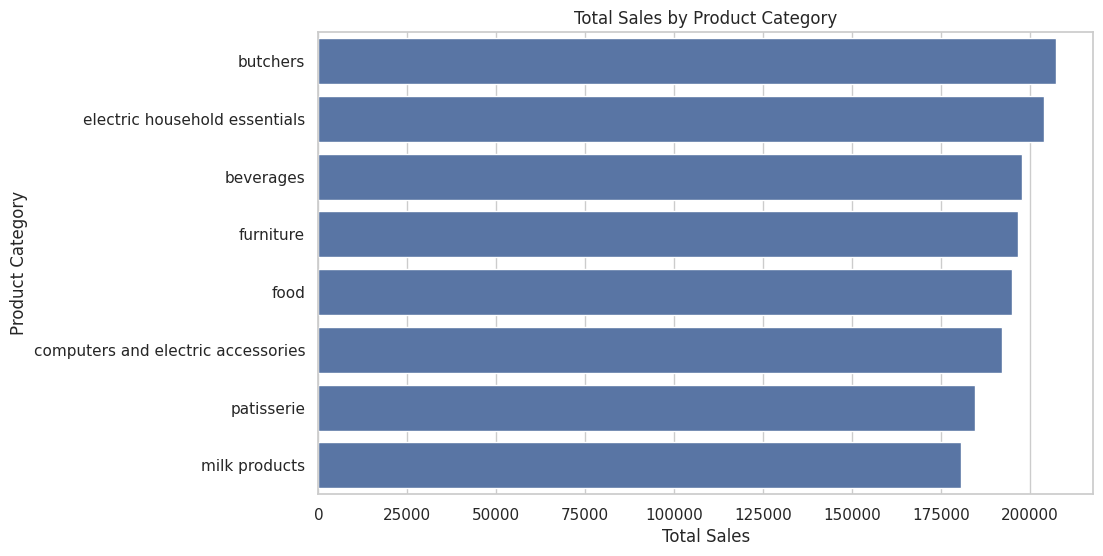

In [ ]:
# ==========================================================
# KEY BUSINESS INSIGHT VISUALIZATION
# ==========================================================

category_sales = clean_df.groupby("Category")["Total Spent"].sum()
category_sales = category_sales.sort_values(ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    x=category_sales.values,
    y=category_sales.index
)

plt.title("Total Sales by Product Category")
plt.xlabel("Total Sales")
plt.ylabel("Product Category")

plt.show()

Observation:

This bar chart shows total sales by product category. Butchers and
Electric Household Essentials generate the highest revenue, while
Milk Products and Patisserie perform the lowest. This suggests the
store should focus more resources on top-performing categories to
maximize profit.

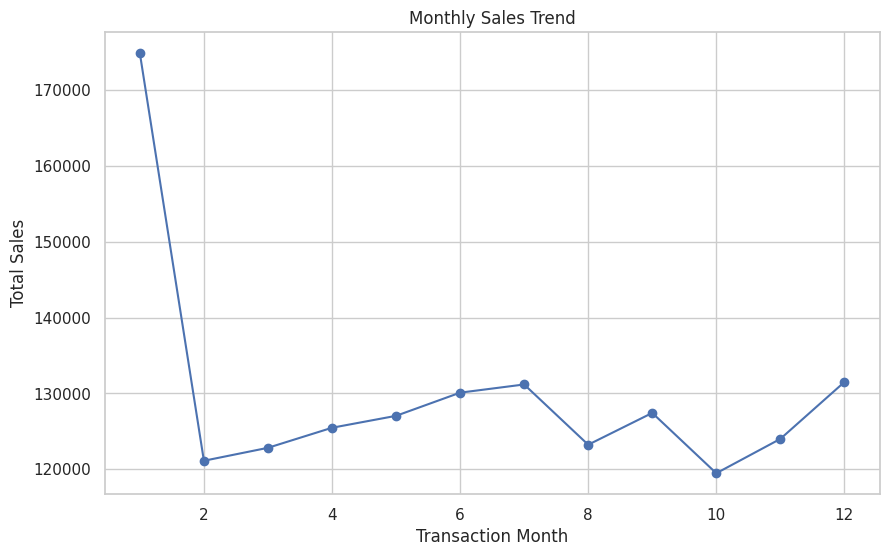

In [ ]:
# Monthly sales trend

monthly_sales = clean_df.groupby("Transaction Month")["Total Spent"].sum()

plt.figure(figsize=(10,6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Transaction Month")
plt.ylabel("Total Sales")

plt.show()

Observation:

This line chart shows monthly sales trends throughout the year.
January records the highest sales, followed by a sharp drop in
February. Sales remain relatively stable for the rest of the year.
The store could use promotions during low-sales months to boost revenue.

##**Final Conclusion**

This project successfully analysed retail store sales data through
data cleaning, exploratory data analysis, feature engineering, and
machine learning classification.

Four models were trained and evaluated: Logistic Regression, KNN,
Decision Tree, and Random Forest. The Tuned Random Forest model was
selected as the best model, achieving approximately 99.5% accuracy
and F1-score on the testing dataset. It provided strong and reliable
performance while minimising the risk of overfitting compared to the
Decision Tree model.

PCA dimensionality reduction was also applied, but it slightly reduced
model performance from 99% to 87%, suggesting that the original
features contained important information that PCA removed.

Overall, the project successfully demonstrated that machine learning
can effectively classify customer spending behaviour and provide useful
insights for retail business analysis.


##**Business Recommendation**

- Focus inventory and marketing resources on top-selling categories
  such as Butchers and Electric Household Essentials.
- Run targeted promotions during low-sales months (February and
  October) to boost revenue.
- Use the Tuned Random Forest model for ongoing customer spending
  classification and sales prediction.
- Monitor Medium and Low spending customers closely, as these groups
  showed the most misclassification and represent growth opportunities.
- Regularly update and retrain the model with new transaction data to
  maintain prediction accuracy over time.
- Continue applying data cleaning and preprocessing to ensure data
  quality for reliable predictions.

